# 📊 03 - Evaluation & Visualization: Multitask RUL + Fault Classification

In [11]:
# 📦 Load packages
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, roc_auc_score

import os
import sys
sys.path.append(os.path.abspath("../src"))  # Adjust path to include src directory
from multitask_model import MultiTaskLSTM
from torch.utils.data import DataLoader, TensorDataset


In [12]:
# 📥 Load data and model
X = np.load('outputs/X.npy')
y_reg = np.load('outputs/y_reg.npy')
y_cls = np.load('outputs/y_cls.npy')

X_tensor = torch.tensor(X, dtype=torch.float32)
y_reg_tensor = torch.tensor(y_reg, dtype=torch.float32)
y_cls_tensor = torch.tensor(y_cls, dtype=torch.float32)

val_loader = DataLoader(TensorDataset(X_tensor, y_reg_tensor, y_cls_tensor), batch_size=128)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MultiTaskLSTM(input_dim=X.shape[2]).to(device)
model.load_state_dict(torch.load('models/multitask_lstm.pt', map_location=device))
model.eval()

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/X.npy'

In [ ]:
# 🔍 Get predictions
y_true_reg, y_true_cls = [], []
y_pred_reg, y_pred_cls = [], []

with torch.no_grad():
    for xb, yb_reg, yb_cls in val_loader:
        xb = xb.to(device)
        reg_out, cls_out = model(xb)
        y_pred_reg.append(reg_out.cpu().numpy())
        y_pred_cls.append(cls_out.cpu().numpy())
        y_true_reg.append(yb_reg.numpy())
        y_true_cls.append(yb_cls.numpy())

y_pred_reg = np.vstack(y_pred_reg)
y_pred_cls = np.vstack(y_pred_cls)
y_true_reg = np.vstack(y_true_reg)
y_true_cls = np.vstack(y_true_cls)

In [ ]:
# 📊 Regression Metrics (RUL)
for i, comp in enumerate(['comp1', 'comp2', 'comp3']):
    mse = mean_squared_error(y_true_reg[:, i], y_pred_reg[:, i])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_reg[:, i], y_pred_reg[:, i])
    print(f"{comp} - RMSE: {rmse:.2f}, MAE: {mae:.2f}")

comp1 - RMSE: 8.83, MAE: 7.39
comp2 - RMSE: 7.34, MAE: 5.94
comp3 - RMSE: 8.66, MAE: 7.10


In [ ]:
# ✅ Classification Metrics (Fault detection)
for i, comp in enumerate(['comp1', 'comp2', 'comp3']):
    try:
        auc = roc_auc_score(y_true_cls[:, i], y_pred_cls[:, i])
        print(f"{comp} - ROC AUC: {auc:.3f}")
    except:
        print(f"{comp} - ROC AUC: Cannot compute (labels uniform)")

comp1 - ROC AUC: 0.533
comp2 - ROC AUC: 0.648
comp3 - ROC AUC: 0.479


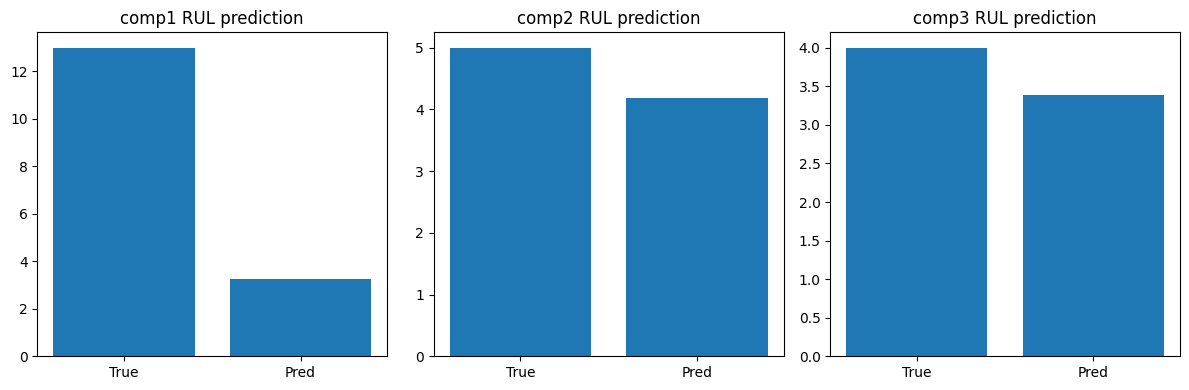

In [ ]:
# 📈 Sample visualization
sample_idx = 10
plt.figure(figsize=(12, 4))
for i, comp in enumerate(['comp1', 'comp2', 'comp3']):
    plt.subplot(1, 3, i+1)
    plt.title(f"{comp} RUL prediction")
    plt.bar(['True', 'Pred'], [y_true_reg[sample_idx, i], y_pred_reg[sample_idx, i]])
plt.tight_layout()
plt.show()